# Brain MRI Tumor Classification with a CNN

Dataset: [Brain Tumor MRI Dataset](https://huggingface.co/datasets/BJyotibrat/Masoud-Nickparvar-Brain-Tumor-MRI-Dataset) (Masoud Nickparvar, CC BY 4.0) - 7,200 MRI slices in four classes: **glioma, meningioma, pituitary, no tumor**.

**Labeling note:** an earlier version of this notebook used `mars-hm/tumor_cnn` and inferred labels from each image's parent folder. In that dataset every image sits in one `train/` folder and every scan is tumor-positive (its annotations are segmentation polygons, not classes), so all images got the same label and the model trivially scored 100%. This version uses a dataset with real class labels and checks that more than one class is present.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from datasets import load_dataset

from torchvision import transforms

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Data and labels

In [3]:
DATASET = "BJyotibrat/Masoud-Nickparvar-Brain-Tumor-MRI-Dataset"

ds = load_dataset(DATASET)   # first run downloads ~7,200 images (~170 MB)
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 7200
    })
})

In [4]:
# Labels come from the dataset's class folders (Training/<class>/..., Testing/<class>/...)
print("Splits:", list(ds.keys()))
print("Features:", ds["train"].features)

classes = ds["train"].features["label"].names
label2id = {c: i for i, c in enumerate(classes)}
id2label = {i: c for c, i in label2id.items()}

counts = np.bincount(ds["train"]["label"], minlength=len(classes))
print("Images per class:", dict(zip(classes, counts.tolist())))

# Guard against the earlier bug: a classifier needs at least two classes with examples
present = set(ds["train"]["label"])
assert len(present) >= 2, f"Only {len(present)} class(es) found - labels are broken."

Splits: ['train']
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['glioma', 'meningioma', 'notumor', 'pituitary'])}
Images per class: {'glioma': 1800, 'meningioma': 1800, 'notumor': 1800, 'pituitary': 1800}


In [5]:
# The Hub serves all 7,200 images as one split; the original Training/Testing folders are in the file paths.
# Keep the official Testing images as an untouched test set, and carve validation out of Training (90/10, stratified).
from datasets import Image as HFImage

paths = [x["path"].replace("\\", "/") for x in ds["train"].cast_column("image", HFImage(decode=False))["image"]]
test_idx = [i for i, p in enumerate(paths) if "/Testing/" in p]
train_idx = [i for i, p in enumerate(paths) if "/Training/" in p]
assert len(test_idx) + len(train_idx) == len(paths)

tmp = ds["train"].select(train_idx).train_test_split(test_size=0.1, seed=42, stratify_by_column="label")
train_ds = tmp["train"]
val_ds = tmp["test"]
test_ds = ds["train"].select(test_idx)

print("Train/Val/Test sizes:", len(train_ds), len(val_ds), len(test_ds))

def label_counts(hf_ds):
    labels = hf_ds["label"]
    unique, counts = np.unique(labels, return_counts=True)
    return {id2label[u]: c for u, c in zip(unique.tolist(), counts.tolist())}

print("Train label counts:", label_counts(train_ds))
print("Val label counts:", label_counts(val_ds))
print("Test label counts:", label_counts(test_ds))

Train/Val/Test sizes: 5040 560 1600
Train label counts: {'glioma': 1260, 'meningioma': 1260, 'notumor': 1260, 'pituitary': 1260}
Val label counts: {'glioma': 140, 'meningioma': 140, 'notumor': 140, 'pituitary': 140}
Test label counts: {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


## Transforms and data loaders

In [6]:
from torchvision import transforms

IMG_SIZE = 128

# Common ImageNet normalization values (fine even if not using pretrained models)
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD  = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),        # force 3-channel
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),                                    # -> [0, 1]
    transforms.Normalize(NORM_MEAN, NORM_STD),                # standardize
])

eval_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

In [7]:
class HFDatasetTorch(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, image_col="image", label_col="label", transform=None):
        self.ds = hf_dataset
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item[self.image_col]  # PIL image (HF Image)
        y = item[self.label_col]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(y, dtype=torch.long)

In [8]:
BATCH_SIZE = 16

train_torch = HFDatasetTorch(train_ds, transform=train_transform)
val_torch   = HFDatasetTorch(val_ds, transform=eval_transform)
test_torch  = HFDatasetTorch(test_ds, transform=eval_transform)

train_loader = DataLoader(train_torch, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_torch, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_torch, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x0, y0 = next(iter(train_loader))
print("Batch X shape:", x0.shape)
print("Batch y:", y0[:20].tolist())
print("Unique labels in batch:", sorted(set(y0.tolist())))

# Check a few batches
for b, (xb, yb) in enumerate(train_loader):
    if b == 5:
        break
    print(f"batch {b}: unique labels ->", sorted(set(yb.tolist())))

Batch X shape: torch.Size([16, 3, 128, 128])
Batch y: [1, 1, 0, 0, 2, 0, 2, 0, 3, 1, 2, 3, 3, 1, 2, 3]
Unique labels in batch: [0, 1, 2, 3]
batch 0: unique labels -> [0, 1, 2, 3]
batch 1: unique labels -> [0, 1, 2, 3]


batch 2: unique labels -> [0, 1, 2, 3]
batch 3: unique labels -> [0, 1, 2, 3]
batch 4: unique labels -> [0, 1, 2, 3]


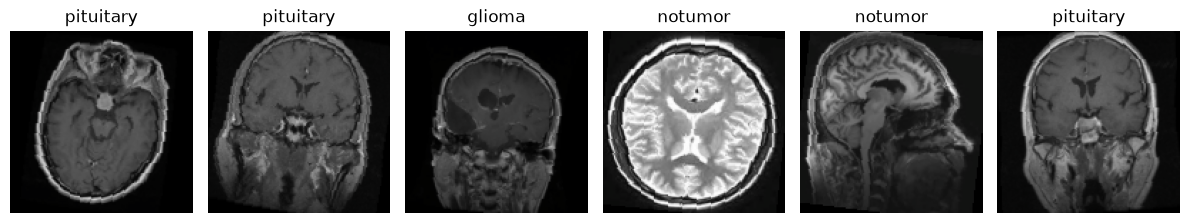

In [9]:
def show_batch(loader, n=6):
    imgs, labels = next(iter(loader))
    imgs = imgs[:n]
    labels = labels[:n].numpy()

    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = imgs[i].permute(1, 2, 0).numpy() * np.array(NORM_STD) + np.array(NORM_MEAN)  # undo normalization
        img = img.clip(0, 1)
        plt.imshow(img)
        plt.title(id2label[int(labels[i])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, n=6)

## Model

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            out = self.features(dummy)
            flat_dim = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

num_classes = len(classes)
model = SimpleCNN(num_classes).to(device)
model

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=32768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3,

## Training

In [11]:
LR = 1e-3
EPOCHS = 12

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print("Hyperparameters")
print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("LR:", LR)
print("EPOCHS:", EPOCHS)
print("Classes:", classes)

Hyperparameters
IMG_SIZE: 128
BATCH_SIZE: 16
LR: 0.001
EPOCHS: 12
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [12]:
import torch.nn.functional as F

@torch.no_grad()
def eval_loss_and_acc(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds_all, y_all = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds_all.append(torch.argmax(logits, dim=1).cpu())
        y_all.append(y.cpu())
    preds_all = torch.cat(preds_all).numpy()
    y_all = torch.cat(y_all).numpy()
    return total_loss / len(loader.dataset), accuracy_score(y_all, preds_all)

baseline_val_loss, baseline_val_acc = eval_loss_and_acc(model, val_loader, criterion)
print("Before training | val loss:", f"{baseline_val_loss:.10f}", "val acc:", baseline_val_acc)

Before training | val loss: 1.3859867266 val acc: 0.21785714285714286


In [13]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    preds_all, y_all = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)

        preds_all.append(preds.detach().cpu())
        y_all.append(y.detach().cpu())

    preds_all = torch.cat(preds_all).numpy()
    y_all = torch.cat(y_all).numpy()
    acc = accuracy_score(y_all, preds_all)
    return total_loss / len(loader.dataset), acc

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    preds_all, y_all = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)

        preds_all.append(preds.cpu())
        y_all.append(y.cpu())

    preds_all = torch.cat(preds_all).numpy()
    y_all = torch.cat(y_all).numpy()
    acc = accuracy_score(y_all, preds_all)
    return total_loss / len(loader.dataset), acc

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc = -1
best_state = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = eval_one_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
    f"Epoch {epoch:02d}/{EPOCHS} | "
    f"train loss {tr_loss:.10f} acc {tr_acc:.4f} | "
    f"val loss {va_loss:.10f} acc {va_acc:.4f}"
)

model.load_state_dict(best_state)
print("Best val acc:", best_val_acc)

Epoch 01/12 | train loss 1.1568280891 acc 0.6720 | val loss 0.5084392624 acc 0.8125


Epoch 02/12 | train loss 0.6212736670 acc 0.7532 | val loss 0.4424522758 acc 0.8143


Epoch 03/12 | train loss 0.5485863441 acc 0.7776 | val loss 0.4509789203 acc 0.8232


Epoch 04/12 | train loss 0.5184214873 acc 0.7958 | val loss 0.4499276838 acc 0.8268


Epoch 05/12 | train loss 0.4590351655 acc 0.8163 | val loss 0.3495077142 acc 0.8696


...

Epoch 08/12 | train loss 0.3636659018 acc 0.8520 | val loss 0.4135086903 acc 0.8554


Epoch 09/12 | train loss 0.3653450032 acc 0.8556 | val loss 0.2892506746 acc 0.8893


Epoch 10/12 | train loss 0.3292908352 acc 0.8655 | val loss 0.3074639552 acc 0.8875


Epoch 11/12 | train loss 0.3189984401 acc 0.8710 | val loss 0.2714945542 acc 0.8875


Epoch 12/12 | train loss 0.2989141345 acc 0.8815 | val loss 0.2303585848 acc 0.9107
Best val acc: 0.9107142857142857


## Learning curves

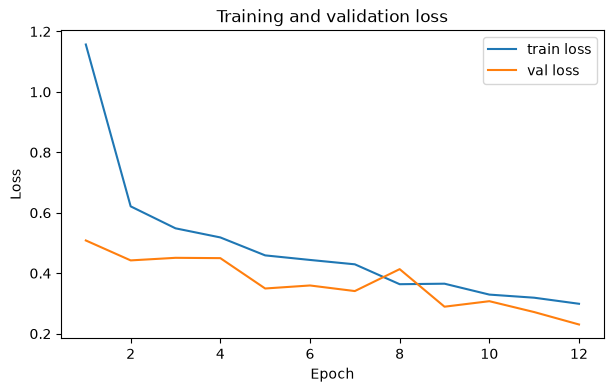

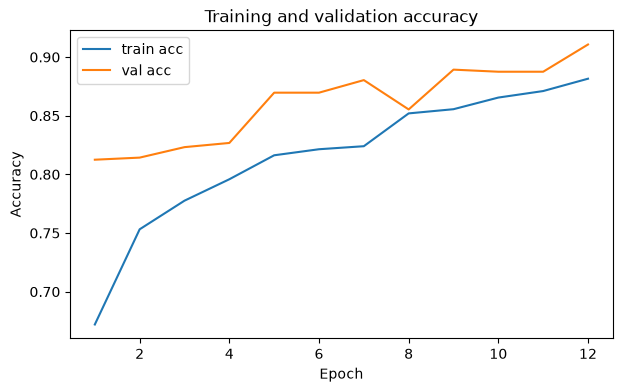

In [14]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["val_acc"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

## Test set evaluation

In [15]:
@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    preds_all, y_all = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu()
        preds_all.append(preds)
        y_all.append(y)
    return torch.cat(preds_all).numpy(), torch.cat(y_all).numpy()

test_preds, test_y = get_preds(model, test_loader)

print("Test accuracy:", accuracy_score(test_y, test_preds))
print("\nClassification report:")
print(classification_report(test_y, test_preds, target_names=[id2label[i] for i in range(num_classes)], digits=3))

cm = confusion_matrix(test_y, test_preds)
cm

Test accuracy: 0.85375

Classification report:
              precision    recall  f1-score   support

      glioma      0.907     0.705     0.793       400
  meningioma      0.782     0.762     0.772       400
     notumor      0.814     0.975     0.887       400
   pituitary      0.926     0.973     0.949       400

    accuracy                          0.854      1600
   macro avg      0.857     0.854     0.850      1600
weighted avg      0.857     0.854     0.850      1600



array([[282,  70,  39,   9],
       [ 23, 305,  50,  22],
       [  5,   5, 390,   0],
       [  1,  10,   0, 389]])

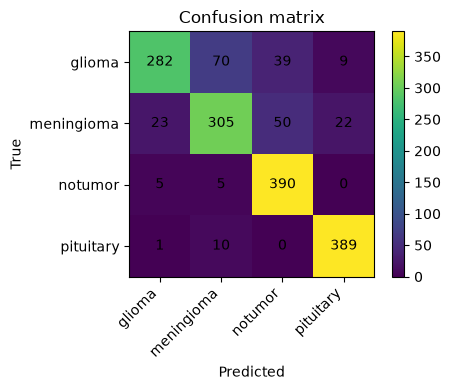

In [16]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion matrix")
plt.colorbar()
plt.xticks(range(num_classes), [id2label[i] for i in range(num_classes)], rotation=45, ha="right")
plt.yticks(range(num_classes), [id2label[i] for i in range(num_classes)])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

In [17]:
acc = accuracy_score(test_y, test_preds)
prec, rec, f1, _ = precision_recall_fscore_support(test_y, test_preds, average="weighted")

metrics_summary = {
    "dataset": DATASET,
    "classes": classes,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "epochs": EPOCHS,
    "best_val_acc": float(best_val_acc),
    "test_accuracy": float(acc),
    "weighted_precision": float(prec),
    "weighted_recall": float(rec),
    "weighted_f1": float(f1),
}
metrics_summary

{'dataset': 'BJyotibrat/Masoud-Nickparvar-Brain-Tumor-MRI-Dataset',
 'classes': ['glioma', 'meningioma', 'notumor', 'pituitary'],
 'img_size': 128,
 'batch_size': 16,
 'learning_rate': 0.001,
 'epochs': 12,
 'best_val_acc': 0.9107142857142857,
 'test_accuracy': 0.85375,
 'weighted_precision': 0.8572976029971278,
 'weighted_recall': 0.85375,
 'weighted_f1': 0.850388336334653}